In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

if file_name.endswith('.xlsx') or file_name.endswith('.xls'):
    df = pd.read_excel(file_name)
elif file_name.endswith('.csv'):
    df = pd.read_csv(file_name)
else:
    raise ValueError("Please upload a CSV or Excel file.")

print("Selected file:", file_name)
print("Dataset loaded successfully.")

Saving india_weather_103cities_30mar_13apr.xlsx to india_weather_103cities_30mar_13apr.xlsx
Selected file: india_weather_103cities_30mar_13apr.xlsx
Dataset loaded successfully.


In [ ]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nInference:")
print("The dataset has been successfully loaded.")
print("The columns contain a combination of numerical and categorical attributes.")

Dataset Shape: (12360, 16)

First 5 Rows:


,city,latitude,longitude,init_time,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_type,precipitation_amount,relative_humidity,wind_direction,wind_speed,weather,forecast_datetime,forecast_date
0,Agartala,23.831,91.287,2026-03-29 12:00:00,12,22,1,2,rain,0,98,S,2,ishowerday,2026-03-30 00:00:00,2026-03-30
1,Agartala,23.831,91.287,2026-03-29 12:00:00,15,28,1,-1,rain,0,65,S,3,ishowerday,2026-03-30 03:00:00,2026-03-30
2,Agartala,23.831,91.287,2026-03-29 12:00:00,18,33,2,-1,rain,0,54,SW,3,ishowerday,2026-03-30 06:00:00,2026-03-30
3,Agartala,23.831,91.287,2026-03-29 12:00:00,21,30,8,-1,none,0,51,S,3,cloudyday,2026-03-30 09:00:00,2026-03-30
4,Agartala,23.831,91.287,2026-03-29 12:00:00,24,26,6,-1,rain,0,82,SW,3,oshowerday,2026-03-30 12:00:00,2026-03-30



Column Names:
['city', 'latitude', 'longitude', 'init_time', 'timepoint_hr', 'temperature_c', 'cloud_cover', 'lifted_index', 'precipitation_type', 'precipitation_amount', 'relative_humidity', 'wind_direction', 'wind_speed', 'weather', 'forecast_datetime', 'forecast_date']

Data Types:
city                            object
latitude                       float64
longitude                      float64
init_time               datetime64[ns]
timepoint_hr                     int64
temperature_c                    int64
cloud_cover                      int64
lifted_index                     int64
precipitation_type              object
precipitation_amount             int64
relative_humidity                int64
wind_direction                  object
wind_speed                       int64
weather                         object
forecast_datetime       datetime64[ns]
forecast_date           datetime64[ns]
dtype: object

Inference:
The dataset has been successfully loaded.
The columns contain a

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical Attributes:")
print(numerical_columns)

print("\nCategorical Attributes:")
print(categorical_columns)

print("\nNumber of Numerical Attributes:", len(numerical_columns))
print("Number of Categorical Attributes:", len(categorical_columns))

print("\nInference:")
print("Numerical attributes contain quantitative values and can be used for scaling.")
print("Categorical attributes contain labels or categories and require encoding before")
print("being directly used by most machine learning algorithms.")

Numerical Attributes:
['latitude', 'longitude', 'timepoint_hr', 'temperature_c', 'cloud_cover', 'lifted_index', 'precipitation_amount', 'relative_humidity', 'wind_speed']

Categorical Attributes:
['city', 'precipitation_type', 'wind_direction', 'weather']

Number of Numerical Attributes: 9
Number of Categorical Attributes: 4

Inference:
Numerical attributes contain quantitative values and can be used for scaling.
Categorical attributes contain labels or categories and require encoding before
being directly used by most machine learning algorithms.


In [ ]:
skewness = df[numerical_columns].skew()

print("Skewness of Numerical Attributes:")
display(skewness.to_frame("Skewness"))

print("\nINFERENCES:")

for column in numerical_columns:
    value = skewness[column]

    if value > 1:
        print(f"{column}: Highly positively skewed (right-skewed), Skewness = {value:.3f}")
    elif value > 0.5:
        print(f"{column}: Moderately positively skewed, Skewness = {value:.3f}")
    elif value > 0:
        print(f"{column}: Slightly positively skewed, Skewness = {value:.3f}")
    elif value < -1:
        print(f"{column}: Highly negatively skewed (left-skewed), Skewness = {value:.3f}")
    elif value < -0.5:
        print(f"{column}: Moderately negatively skewed, Skewness = {value:.3f}")
    elif value < 0:
        print(f"{column}: Slightly negatively skewed, Skewness = {value:.3f}")
    else:
        print(f"{column}: Approximately symmetric, Skewness = {value:.3f}")

Skewness of Numerical Attributes:


,Skewness
latitude,-0.370415
longitude,0.997870
timepoint_hr,0.000000
temperature_c,-0.461710
cloud_cover,0.122580
lifted_index,-0.218636
precipitation_amount,0.337191
relative_humidity,1.107328
wind_speed,1.030938



INFERENCES:
latitude: Slightly negatively skewed, Skewness = -0.370
longitude: Moderately positively skewed, Skewness = 0.998
timepoint_hr: Approximately symmetric, Skewness = 0.000
temperature_c: Slightly negatively skewed, Skewness = -0.462
cloud_cover: Slightly positively skewed, Skewness = 0.123
lifted_index: Slightly negatively skewed, Skewness = -0.219
precipitation_amount: Slightly positively skewed, Skewness = 0.337
relative_humidity: Highly positively skewed (right-skewed), Skewness = 1.107
wind_speed: Highly positively skewed (right-skewed), Skewness = 1.031


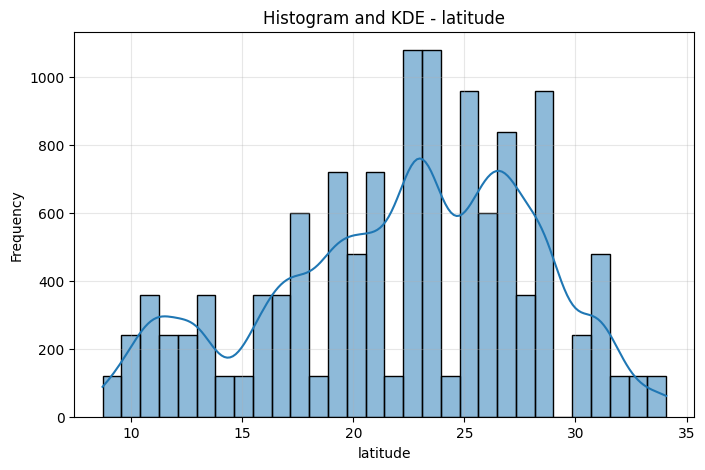

Inference for latitude:
The distribution is slightly negatively skewed.



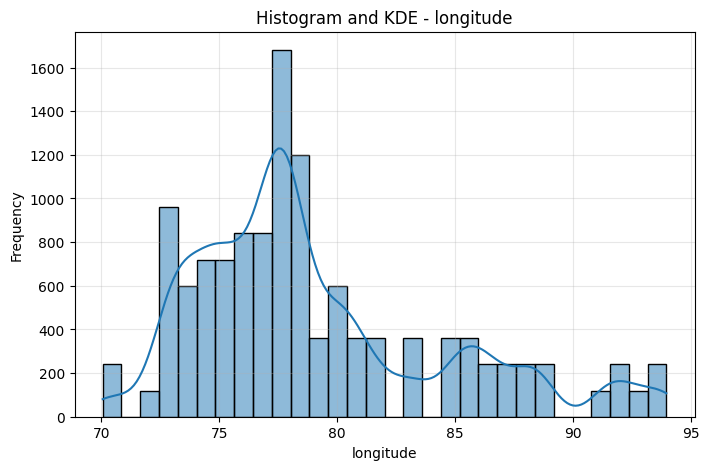

Inference for longitude:
The distribution is moderately positively skewed.
The histogram shows a tendency toward higher values.



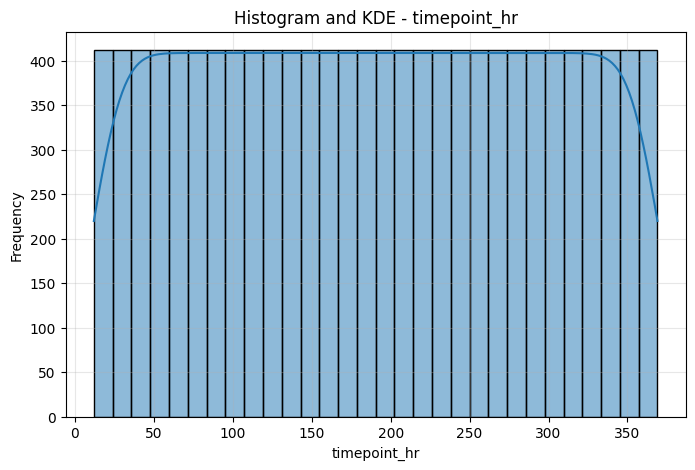

Inference for timepoint_hr:
The distribution is approximately symmetric.



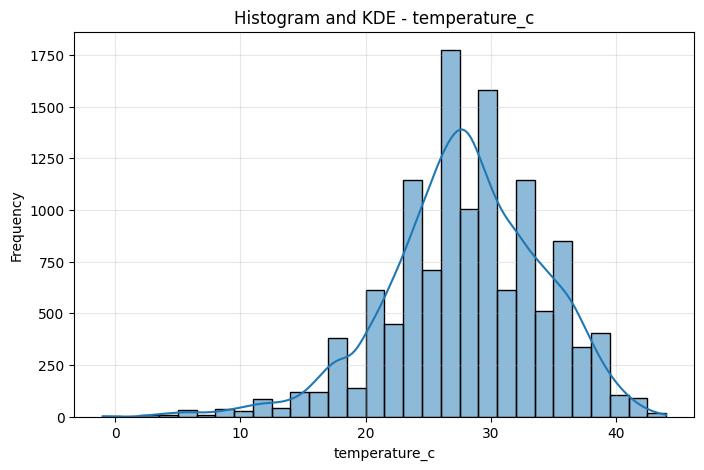

Inference for temperature_c:
The distribution is slightly negatively skewed.



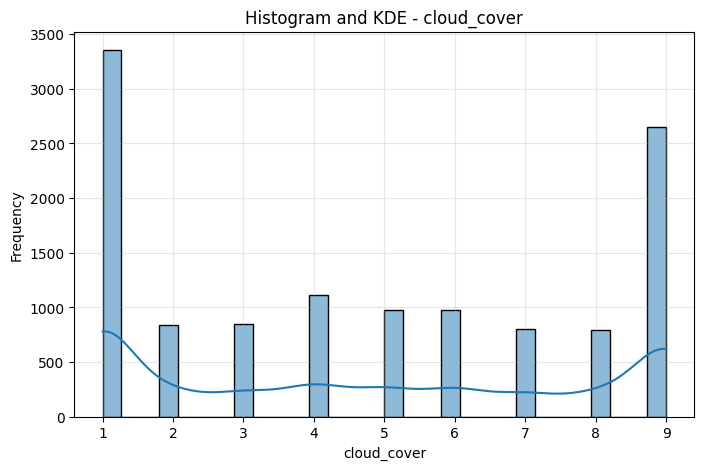

Inference for cloud_cover:
The distribution is slightly positively skewed.



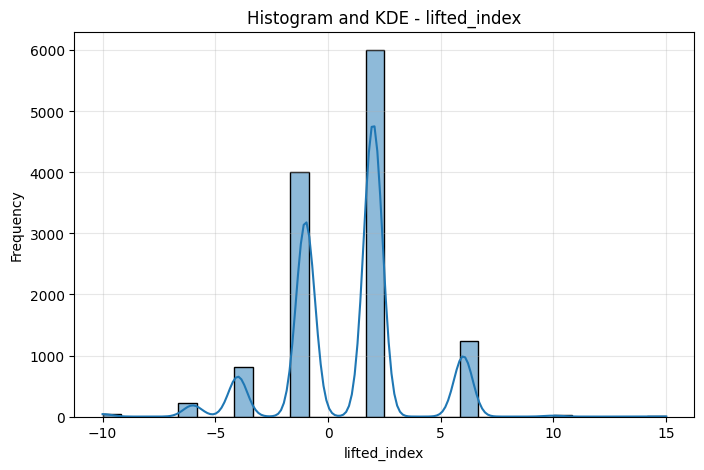

Inference for lifted_index:
The distribution is slightly negatively skewed.



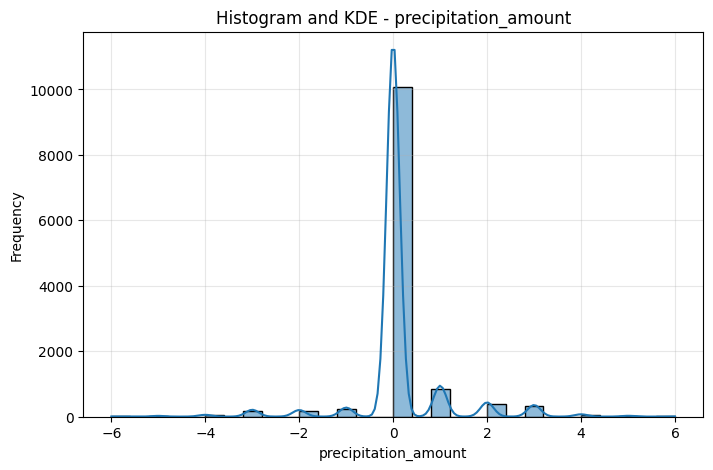

Inference for precipitation_amount:
The distribution is slightly positively skewed.



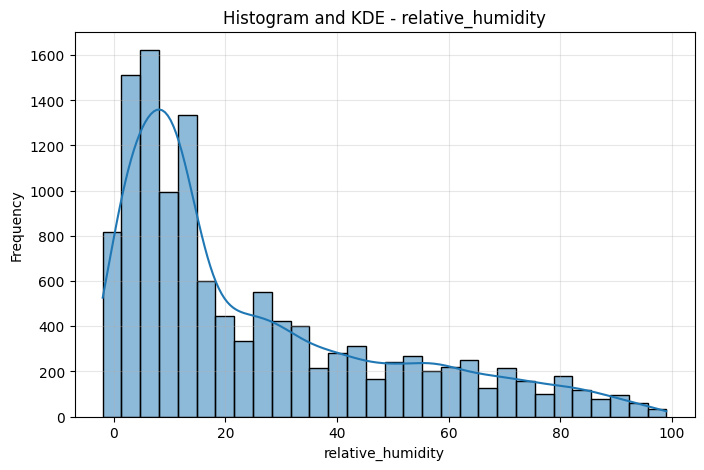

Inference for relative_humidity:
The distribution is highly positively skewed.
The histogram has a long tail toward higher values.



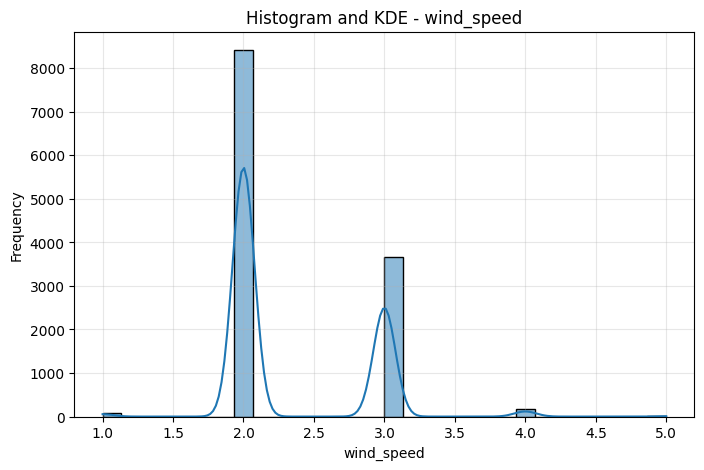

Inference for wind_speed:
The distribution is highly positively skewed.
The histogram has a long tail toward higher values.



In [ ]:
for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[column].dropna(),
        kde=True,
        bins=30
    )

    plt.title(f"Histogram and KDE - {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

    value = df[column].skew()

    print(f"Inference for {column}:")

    if value > 1:
        print("The distribution is highly positively skewed.")
        print("The histogram has a long tail toward higher values.")

    elif value > 0.5:
        print("The distribution is moderately positively skewed.")
        print("The histogram shows a tendency toward higher values.")

    elif value > 0:
        print("The distribution is slightly positively skewed.")

    elif value < -1:
        print("The distribution is highly negatively skewed.")
        print("The histogram has a long tail toward lower values.")

    elif value < -0.5:
        print("The distribution is moderately negatively skewed.")
        print("The histogram shows a tendency toward lower values.")

    elif value < 0:
        print("The distribution is slightly negatively skewed.")

    else:
        print("The distribution is approximately symmetric.")

    print()

In [ ]:
manual_minmax = df[numerical_columns].copy()

for column in numerical_columns:

    minimum = manual_minmax[column].min()
    maximum = manual_minmax[column].max()

    manual_minmax[column] = (
        manual_minmax[column] - minimum
    ) / (maximum - minimum)

print("Manually Min-Max Scaled Data:")
display(manual_minmax.head())

print("\nInference:")
print("Min-Max scaling transforms numerical attributes to a common range of 0 to 1.")
print("This prevents attributes with larger numerical ranges from dominating")
print("attributes with smaller numerical ranges.")

Manually Min-Max Scaled Data:


,latitude,longitude,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_amount,relative_humidity,wind_speed
0,0.595877,0.888498,0.000000,0.511111,0.000,0.48,0.5,0.990099,0.25
1,0.595877,0.888498,0.008403,0.644444,0.000,0.36,0.5,0.663366,0.50
2,0.595877,0.888498,0.016807,0.755556,0.125,0.36,0.5,0.554455,0.50
3,0.595877,0.888498,0.025210,0.688889,0.875,0.36,0.5,0.524752,0.50
4,0.595877,0.888498,0.033613,0.600000,0.625,0.36,0.5,0.831683,0.50



Inference:
Min-Max scaling transforms numerical attributes to a common range of 0 to 1.
This prevents attributes with larger numerical ranges from dominating
attributes with smaller numerical ranges.


In [ ]:
manual_min = manual_minmax.min()
manual_max = manual_minmax.max()

verification_manual = pd.DataFrame({
    "Minimum": manual_min,
    "Maximum": manual_max
})

display(verification_manual)

print("\nInference:")

if (
    np.allclose(manual_min.values, 0) and
    np.allclose(manual_max.values, 1)
):
    print("Manual Min-Max scaling was successfully performed.")
    print("The minimum of every numerical attribute is approximately 0.")
    print("The maximum of every numerical attribute is approximately 1.")
else:
    print("Some attributes do not have the expected 0 to 1 range.")

,Minimum,Maximum
latitude,0.0,1.0
longitude,0.0,1.0
timepoint_hr,0.0,1.0
temperature_c,0.0,1.0
cloud_cover,0.0,1.0
lifted_index,0.0,1.0
precipitation_amount,0.0,1.0
relative_humidity,0.0,1.0
wind_speed,0.0,1.0



Inference:
Manual Min-Max scaling was successfully performed.
The minimum of every numerical attribute is approximately 0.
The maximum of every numerical attribute is approximately 1.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

sklearn_minmax = pd.DataFrame(
    scaler.fit_transform(df[numerical_columns]),
    columns=numerical_columns,
    index=df.index
)

print("Scikit-Learn Min-Max Scaled Data:")
display(sklearn_minmax.head())

print("\nInference:")
print("Scikit-Learn MinMaxScaler has successfully normalized the numerical attributes.")
print("All transformed numerical attributes are scaled to the range 0 to 1.")

Scikit-Learn Min-Max Scaled Data:


,latitude,longitude,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_amount,relative_humidity,wind_speed
0,0.595877,0.888498,0.000000,0.511111,0.000,0.48,0.5,0.990099,0.25
1,0.595877,0.888498,0.008403,0.644444,0.000,0.36,0.5,0.663366,0.50
2,0.595877,0.888498,0.016807,0.755556,0.125,0.36,0.5,0.554455,0.50
3,0.595877,0.888498,0.025210,0.688889,0.875,0.36,0.5,0.524752,0.50
4,0.595877,0.888498,0.033613,0.600000,0.625,0.36,0.5,0.831683,0.50



Inference:
Scikit-Learn MinMaxScaler has successfully normalized the numerical attributes.
All transformed numerical attributes are scaled to the range 0 to 1.


In [ ]:
difference = np.abs(
    manual_minmax.values - sklearn_minmax.values
)

maximum_difference = difference.max()

print("Maximum difference between Manual and Scikit-Learn scaling:")
print(maximum_difference)

print("\nInference:")

if np.allclose(manual_minmax.values, sklearn_minmax.values):
    print("Manual Min-Max scaling and Scikit-Learn MinMaxScaler produce equivalent results.")
    print("This verifies the correctness of the manually implemented Min-Max formula.")
else:
    print("A difference exists between the two scaling methods.")

Maximum difference between Manual and Scikit-Learn scaling:
3.608224830031759e-16

Inference:
Manual Min-Max scaling and Scikit-Learn MinMaxScaler produce equivalent results.
This verifies the correctness of the manually implemented Min-Max formula.


In [ ]:
if 'education_level' in df.columns:

    ordinal_mapping = {
        'Bachelor': 0,
        'Master': 1,
        'PhD': 2
    }

    df['education_level_encoded'] = df['education_level'].map(
        ordinal_mapping
    )

    display(
        df[['education_level', 'education_level_encoded']].head()
    )

    print("\nInference:")
    print("The ordinal categorical variable has been converted into numerical labels.")
    print("The natural order is preserved as:")
    print("Bachelor < Master < PhD")

else:

    print("No ordinal categorical attribute such as 'education_level' exists")
    print("in the selected dataset.")

    print("\nExample ordinal mapping:")
    print("Bachelor -> 0")
    print("Master   -> 1")
    print("PhD      -> 2")

    print("\nInference:")
    print("The selected weather dataset does not contain an ordinal categorical attribute.")
    print("Therefore, label encoding is demonstrated conceptually using Education Level.")

No ordinal categorical attribute such as 'education_level' exists
in the selected dataset.

Example ordinal mapping:
Bachelor -> 0
Master   -> 1
PhD      -> 2

Inference:
The selected weather dataset does not contain an ordinal categorical attribute.
Therefore, label encoding is demonstrated conceptually using Education Level.


In [ ]:
nominal_columns = categorical_columns.copy()

one_hot_data = pd.get_dummies(
    df[nominal_columns],
    drop_first=True,
    dtype=int
)

print("Original Categorical Columns:")
print(nominal_columns)

print("\nNumber of Original Categorical Columns:")
print(len(nominal_columns))

print("\nNumber of Columns After One-Hot Encoding:")
print(one_hot_data.shape[1])

print("\nOne-Hot Encoded Data:")
display(one_hot_data.head())

print("\nInference:")
print("Nominal categorical attributes have been converted into binary dummy variables.")
print("drop_first=True removes the first category of each categorical attribute.")
print("This prevents the Dummy Variable Trap and reduces redundant information.")

Original Categorical Columns:
['city', 'precipitation_type', 'wind_direction', 'weather']

Number of Original Categorical Columns:
4

Number of Columns After One-Hot Encoding:
134

One-Hot Encoded Data:


,city_Agra,city_Ahmedabad,city_Aizawl,city_Ajmer,city_Akola,city_Aligarh,city_Allahabad,city_Ambattur,city_Amravati,city_Amritsar,...,weather_oshowerday,weather_oshowernight,weather_pcloudyday,weather_pcloudynight,weather_rainday,weather_rainnight,weather_tsday,weather_tsnight,weather_tsrainday,weather_tsrainnight
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0



Inference:
Nominal categorical attributes have been converted into binary dummy variables.
drop_first=True removes the first category of each categorical attribute.
This prevents the Dummy Variable Trap and reduces redundant information.


In [ ]:
transformed_df = pd.concat(
    [
        sklearn_minmax,
        one_hot_data
    ],
    axis=1
)

print("Original Dataset Shape:", df.shape)
print("Transformed Dataset Shape:", transformed_df.shape)

print("\nTransformed Dataset:")
display(transformed_df.head())

print("\nInference:")
print("The transformed dataset contains normalized numerical attributes")
print("and one-hot encoded categorical attributes.")

if transformed_df.shape[1] > df.shape[1]:
    print("The number of columns increased because categorical variables")
    print("were converted into multiple dummy variables.")

Original Dataset Shape: (12360, 16)
Transformed Dataset Shape: (12360, 143)

Transformed Dataset:


,latitude,longitude,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_amount,relative_humidity,wind_speed,city_Agra,...,weather_oshowerday,weather_oshowernight,weather_pcloudyday,weather_pcloudynight,weather_rainday,weather_rainnight,weather_tsday,weather_tsnight,weather_tsrainday,weather_tsrainnight
0,0.595877,0.888498,0.000000,0.511111,0.000,0.48,0.5,0.990099,0.25,0,...,0,0,0,0,0,0,0,0,0,0
1,0.595877,0.888498,0.008403,0.644444,0.000,0.36,0.5,0.663366,0.50,0,...,0,0,0,0,0,0,0,0,0,0
2,0.595877,0.888498,0.016807,0.755556,0.125,0.36,0.5,0.554455,0.50,0,...,0,0,0,0,0,0,0,0,0,0
3,0.595877,0.888498,0.025210,0.688889,0.875,0.36,0.5,0.524752,0.50,0,...,0,0,0,0,0,0,0,0,0,0
4,0.595877,0.888498,0.033613,0.600000,0.625,0.36,0.5,0.831683,0.50,0,...,1,0,0,0,0,0,0,0,0,0



Inference:
The transformed dataset contains normalized numerical attributes
and one-hot encoded categorical attributes.
The number of columns increased because categorical variables
were converted into multiple dummy variables.


In [ ]:
print("ORIGINAL DATASET")
display(df.head())

print("\nInference:")
print("The original dataset contains numerical values in their original scales")
print("and categorical attributes represented using text labels.")

ORIGINAL DATASET


,city,latitude,longitude,init_time,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_type,precipitation_amount,relative_humidity,wind_direction,wind_speed,weather,forecast_datetime,forecast_date
0,Agartala,23.831,91.287,2026-03-29 12:00:00,12,22,1,2,rain,0,98,S,2,ishowerday,2026-03-30 00:00:00,2026-03-30
1,Agartala,23.831,91.287,2026-03-29 12:00:00,15,28,1,-1,rain,0,65,S,3,ishowerday,2026-03-30 03:00:00,2026-03-30
2,Agartala,23.831,91.287,2026-03-29 12:00:00,18,33,2,-1,rain,0,54,SW,3,ishowerday,2026-03-30 06:00:00,2026-03-30
3,Agartala,23.831,91.287,2026-03-29 12:00:00,21,30,8,-1,none,0,51,S,3,cloudyday,2026-03-30 09:00:00,2026-03-30
4,Agartala,23.831,91.287,2026-03-29 12:00:00,24,26,6,-1,rain,0,82,SW,3,oshowerday,2026-03-30 12:00:00,2026-03-30



Inference:
The original dataset contains numerical values in their original scales
and categorical attributes represented using text labels.


In [ ]:
print("TRANSFORMED DATASET")
display(transformed_df.head())

print("\nInference:")
print("The transformed dataset contains numerical values normalized between 0 and 1")
print("and categorical variables represented using binary numerical columns.")
print("The transformed representation is more suitable for machine learning algorithms.")

TRANSFORMED DATASET


,latitude,longitude,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_amount,relative_humidity,wind_speed,city_Agra,...,weather_oshowerday,weather_oshowernight,weather_pcloudyday,weather_pcloudynight,weather_rainday,weather_rainnight,weather_tsday,weather_tsnight,weather_tsrainday,weather_tsrainnight
0,0.595877,0.888498,0.000000,0.511111,0.000,0.48,0.5,0.990099,0.25,0,...,0,0,0,0,0,0,0,0,0,0
1,0.595877,0.888498,0.008403,0.644444,0.000,0.36,0.5,0.663366,0.50,0,...,0,0,0,0,0,0,0,0,0,0
2,0.595877,0.888498,0.016807,0.755556,0.125,0.36,0.5,0.554455,0.50,0,...,0,0,0,0,0,0,0,0,0,0
3,0.595877,0.888498,0.025210,0.688889,0.875,0.36,0.5,0.524752,0.50,0,...,0,0,0,0,0,0,0,0,0,0
4,0.595877,0.888498,0.033613,0.600000,0.625,0.36,0.5,0.831683,0.50,0,...,1,0,0,0,0,0,0,0,0,0



Inference:
The transformed dataset contains numerical values normalized between 0 and 1
and categorical variables represented using binary numerical columns.
The transformed representation is more suitable for machine learning algorithms.


In [ ]:
minmax_statistics = pd.DataFrame({
    'Minimum': sklearn_minmax.min(),
    'Maximum': sklearn_minmax.max()
})

print("Min-Max Scaling Statistics:")
display(minmax_statistics)

print("\nInference:")

if (
    np.allclose(sklearn_minmax.min().values, 0) and
    np.allclose(sklearn_minmax.max().values, 1)
):
    print("Verification successful.")
    print("All numerical attributes have minimum approximately equal to 0")
    print("and maximum approximately equal to 1.")
else:
    print("Some attributes do not have the expected 0 to 1 range.")

Min-Max Scaling Statistics:


,Minimum,Maximum
latitude,0.0,1.0
longitude,0.0,1.0
timepoint_hr,0.0,1.0
temperature_c,0.0,1.0
cloud_cover,0.0,1.0
lifted_index,0.0,1.0
precipitation_amount,0.0,1.0
relative_humidity,0.0,1.0
wind_speed,0.0,1.0



Inference:
Verification successful.
All numerical attributes have minimum approximately equal to 0
and maximum approximately equal to 1.


In [ ]:
manual_standardized = df[numerical_columns].copy()

for column in numerical_columns:

    mean = manual_standardized[column].mean()
    std = manual_standardized[column].std()

    manual_standardized[column] = (
        manual_standardized[column] - mean
    ) / std

print("Manually Standardized Data:")
display(manual_standardized.head())

print("\nInference:")
print("Standardization transforms the numerical attributes so that")
print("they are centered around a mean of 0.")
print("The standard deviation becomes approximately 1.")

Manually Standardized Data:


,latitude,longitude,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_amount,relative_humidity,wind_speed
0,0.282512,2.26344,-1.717607,-0.955656,-1.207543,0.419883,-0.127082,3.003172,-0.624513
1,0.282512,2.26344,-1.688740,0.018134,-1.207543,-0.676698,-0.127082,1.644859,1.315418
2,0.282512,2.26344,-1.659873,0.829626,-0.884940,-0.676698,-0.127082,1.192088,1.315418
3,0.282512,2.26344,-1.631005,0.342731,1.050679,-0.676698,-0.127082,1.068605,1.315418
4,0.282512,2.26344,-1.602138,-0.306463,0.405472,-0.676698,-0.127082,2.344596,1.315418



Inference:
Standardization transforms the numerical attributes so that
they are centered around a mean of 0.
The standard deviation becomes approximately 1.


In [ ]:
standardization_statistics = pd.DataFrame({
    'Mean': manual_standardized.mean(),
    'Standard Deviation': manual_standardized.std()
})

print("Standardization Statistics:")
display(standardization_statistics)

print("\nInference:")

if (
    np.allclose(
        manual_standardized.mean().values,
        0,
        atol=1e-10
    )
    and
    np.allclose(
        manual_standardized.std().values,
        1,
        atol=1e-10
    )
):
    print("Standardization was successfully performed.")
    print("The mean is approximately 0.")
    print("The standard deviation is approximately 1.")
else:
    print("The transformed values are close to the expected standardized properties.")

Standardization Statistics:


,Mean,Standard Deviation
latitude,-4.782941e-16,1.0
longitude,1.931572e-15,1.0
timepoint_hr,-5.748728e-19,1.0
temperature_c,-6.093651e-17,1.0
cloud_cover,6.438575e-17,1.0
lifted_index,-5.058880e-17,1.0
precipitation_amount,1.379695e-17,1.0
relative_humidity,-6.898473e-17,1.0
wind_speed,6.668524e-17,1.0



Inference:
Standardization was successfully performed.
The mean is approximately 0.
The standard deviation is approximately 1.


In [ ]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

sklearn_standardized = pd.DataFrame(
    standard_scaler.fit_transform(df[numerical_columns]),
    columns=numerical_columns,
    index=df.index
)

print("Scikit-Learn Standardized Data:")
display(sklearn_standardized.head())

print("\nInference:")
print("Scikit-Learn StandardScaler has successfully standardized")
print("the numerical attributes.")
print("The features are centered around zero with unit variance.")

Scikit-Learn Standardized Data:


,latitude,longitude,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_amount,relative_humidity,wind_speed
0,0.282523,2.263531,-1.717677,-0.955695,-1.207592,0.419900,-0.127087,3.003294,-0.624539
1,0.282523,2.263531,-1.688808,0.018135,-1.207592,-0.676725,-0.127087,1.644925,1.315471
2,0.282523,2.263531,-1.659940,0.829659,-0.884976,-0.676725,-0.127087,1.192136,1.315471
3,0.282523,2.263531,-1.631071,0.342744,1.050721,-0.676725,-0.127087,1.068648,1.315471
4,0.282523,2.263531,-1.602203,-0.306475,0.405489,-0.676725,-0.127087,2.344691,1.315471



Inference:
Scikit-Learn StandardScaler has successfully standardized
the numerical attributes.
The features are centered around zero with unit variance.


In [ ]:
verification_statistics = pd.DataFrame({
    'Mean': sklearn_standardized.mean(),
    'Std (ddof=0)': sklearn_standardized.std(ddof=0)
})

print("Scikit-Learn Standardization Statistics:")
display(verification_statistics)

print("\nInference:")

if (
    np.allclose(
        sklearn_standardized.mean().values,
        0,
        atol=1e-10
    )
    and
    np.allclose(
        sklearn_standardized.std(ddof=0).values,
        1,
        atol=1e-10
    )
):
    print("Verification successful.")
    print("Mean is approximately 0.")
    print("Standard deviation is approximately 1.")
else:
    print("The results are close to the expected standardized properties.")

Scikit-Learn Standardization Statistics:


,Mean,Std (ddof=0)
latitude,-4.966901e-16,1.0
longitude,1.931572e-15,1.0
timepoint_hr,3.449237e-18,1.0
temperature_c,-5.978677e-17,1.0
cloud_cover,-1.839593e-17,1.0
lifted_index,-4.139084e-17,1.0
precipitation_amount,-5.058880e-17,1.0
relative_humidity,-5.748728e-17,1.0
wind_speed,-4.598982e-18,1.0



Inference:
Verification successful.
Mean is approximately 0.
Standard deviation is approximately 1.


In [ ]:
comparison = pd.DataFrame({
    'Original Mean': df[numerical_columns].mean(),
    'Original Std': df[numerical_columns].std(),
    'Min-Max Min': sklearn_minmax.min(),
    'Min-Max Max': sklearn_minmax.max(),
    'Standardized Mean': sklearn_standardized.mean(),
    'Standardized Std': sklearn_standardized.std(ddof=0)
})

print("STATISTICAL COMPARISON")
display(comparison)

print("\nInference:")
print("The original attributes have different means, standard deviations,")
print("and numerical ranges.")

print("\nAfter Min-Max Scaling:")
print("• Minimum values are approximately 0.")
print("• Maximum values are approximately 1.")

print("\nAfter Standardization:")
print("• Mean values are approximately 0.")
print("• Standard deviations are approximately 1.")

STATISTICAL COMPARISON


,Original Mean,Original Std,Min-Max Min,Min-Max Max,Standardized Mean,Standardized Std
latitude,22.163068,5.903939,0.0,1.0,-4.966901e-16,1.0
longitude,79.080563,5.392870,0.0,1.0,1.931572e-15,1.0
timepoint_hr,190.500000,103.923644,0.0,1.0,3.449237e-18,1.0
temperature_c,27.888269,6.161491,0.0,1.0,-5.978677e-17,1.0
cloud_cover,4.743123,3.099784,0.0,1.0,-1.839593e-17,1.0
lifted_index,0.851294,2.735778,0.0,1.0,-4.139084e-17,1.0
precipitation_amount,0.117395,0.923774,0.0,1.0,-5.058880e-17,1.0
relative_humidity,25.038430,24.294833,0.0,1.0,-5.748728e-17,1.0
wind_speed,2.321926,0.515482,0.0,1.0,-4.598982e-18,1.0



Inference:
The original attributes have different means, standard deviations,
and numerical ranges.

After Min-Max Scaling:
• Minimum values are approximately 0.
• Maximum values are approximately 1.

After Standardization:
• Mean values are approximately 0.
• Standard deviations are approximately 1.


In [ ]:
print("=" * 60)
print("OVERALL OBSERVATIONS AND INFERENCE")
print("=" * 60)

print("\n1. DATASET:")
print("The dataset contains both numerical and categorical attributes.")

print("\n2. SKEWNESS:")
print("Histogram and KDE analysis was used to study the distribution of")
print("numerical attributes.")
print("The skewness values indicate whether an attribute is positively skewed,")
print("negatively skewed, or approximately symmetric.")

print("\n3. MIN-MAX SCALING:")
print("Manual Min-Max scaling and Scikit-Learn MinMaxScaler produce")
print("equivalent results.")
print("The numerical attributes are transformed to the range 0 to 1.")

print("\n4. LABEL ENCODING:")
print("Ordinal categorical variables can be represented using numerical labels")
print("while preserving their natural order.")

print("\n5. ONE-HOT ENCODING:")
print("Nominal categorical variables are converted into binary dummy variables.")
print("Using drop_first=True prevents the Dummy Variable Trap.")

print("\n6. STANDARDIZATION:")
print("Standardization transforms numerical attributes to have a mean")
print("approximately equal to 0 and standard deviation approximately equal to 1.")

print("\n7. FINAL CONCLUSION:")
print("Data preprocessing successfully transformed the original dataset")
print("into a numerical representation suitable for machine learning.")
print("Scaling makes numerical features comparable, while encoding converts")
print("categorical information into a form that machine learning algorithms")
print("can process.")

OVERALL OBSERVATIONS AND INFERENCE

1. DATASET:
The dataset contains both numerical and categorical attributes.

2. SKEWNESS:
Histogram and KDE analysis was used to study the distribution of
numerical attributes.
The skewness values indicate whether an attribute is positively skewed,
negatively skewed, or approximately symmetric.

3. MIN-MAX SCALING:
Manual Min-Max scaling and Scikit-Learn MinMaxScaler produce
equivalent results.
The numerical attributes are transformed to the range 0 to 1.

4. LABEL ENCODING:
Ordinal categorical variables can be represented using numerical labels
while preserving their natural order.

5. ONE-HOT ENCODING:
Nominal categorical variables are converted into binary dummy variables.
Using drop_first=True prevents the Dummy Variable Trap.

6. STANDARDIZATION:
Standardization transforms numerical attributes to have a mean
approximately equal to 0 and standard deviation approximately equal to 1.

7. FINAL CONCLUSION:
Data preprocessing successfully transformed